In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/about data/Plant_1_Generation_Data.csv')
df2 = pd.read_csv('/content/drive/MyDrive/about data/Plant_2_Generation_Data.csv')

In [ ]:
df1.shape

(68778, 7)

In [ ]:
df2.shape

(67698, 7)

In [ ]:
new_df1 = pd.concat([df1,df2])

new_df1.shape

(136476, 7)

In [ ]:
new_df1.isnull().sum()

,0
DATE_TIME,0
PLANT_ID,0
SOURCE_KEY,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,0


In [ ]:
print(f'Number of unique inverters: {new_df1["SOURCE_KEY"].nunique()}')

Number of unique inverters: 44


In [ ]:
new_df1['SOURCE_KEY'].value_counts()

,count
SOURCE_KEY,
xoJJ8DcxJEcupym,3259
WcxssY2VbP4hApt,3259
LYwnQax7tkwH5Cb,3259
LlT2YUhhzqhg5Sw,3259
PeE6FRyGXUgsRhN,3259
81aHJ1q11NBPMrL,3259
V94E5Ben1TlhnDV,3259
oZZkBaNadn6DNKz,3259
q49J1IKaHRwDQnt,3259


In [ ]:
new_df1 = new_df1[new_df1['SOURCE_KEY'] == 'PeE6FRyGXUgsRhN']
new_df1.shape

(3259, 7)

In [ ]:
new_df1.drop(['PLANT_ID','SOURCE_KEY','TOTAL_YIELD'], axis=1, inplace=True)

In [ ]:
new_df1.columns

Index(['DATE_TIME', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD'], dtype='object')

In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/about data/Plant_1_Weather_Sensor_Data.csv')
df2 = pd.read_csv('/content/drive/MyDrive/about data/Plant_2_Weather_Sensor_Data.csv')

In [ ]:
df1.shape

(3182, 6)

In [ ]:
df2.shape

(3259, 6)

In [ ]:
df2.isnull().sum()

,0
DATE_TIME,0
PLANT_ID,0
SOURCE_KEY,0
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0
IRRADIATION,0


In [ ]:
df2.drop(['PLANT_ID','SOURCE_KEY','AMBIENT_TEMPERATURE','IRRADIATION'], axis=1, inplace=True)

In [ ]:
df2.columns

Index(['DATE_TIME', 'MODULE_TEMPERATURE'], dtype='object')

In [ ]:
from datetime import datetime
new_df1['DATE_TIME'] = pd.to_datetime(new_df1['DATE_TIME'])
df2['DATE_TIME'] = pd.to_datetime(df2['DATE_TIME'])

In [ ]:
df = pd.merge(new_df1, df2, on='DATE_TIME', how='right')
df.shape

(3259, 5)

In [ ]:
df.head()

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,MODULE_TEMPERATURE
0,2020-05-15 00:00:00,0.0,0.0,651.2,25.060789
1,2020-05-15 00:15:00,0.0,0.0,0.0,24.421869
2,2020-05-15 00:30:00,0.0,0.0,0.0,24.427290
3,2020-05-15 00:45:00,0.0,0.0,0.0,24.420678
4,2020-05-15 01:00:00,0.0,0.0,0.0,25.088210


<Axes: >

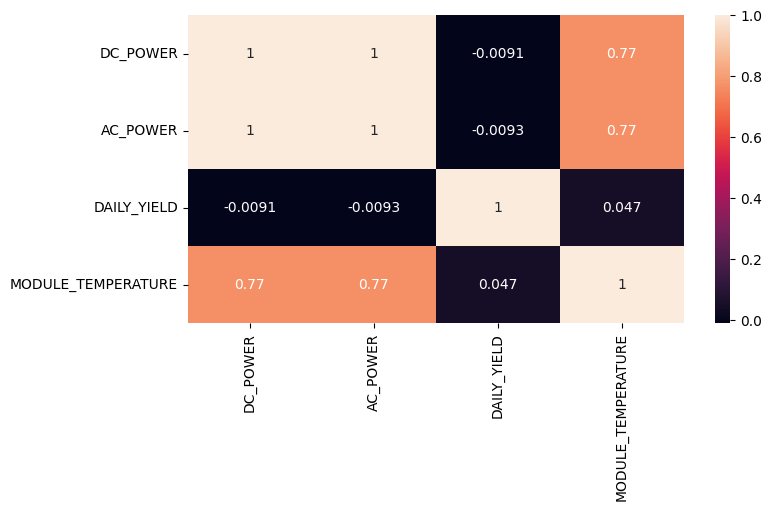

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
df.isnull().sum()

,0
DATE_TIME,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
MODULE_TEMPERATURE,0


In [ ]:
df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], format = '%Y-%m-%d H:M')
df["HOUR"] = df["DATE_TIME"].dt.hour
df["MINUTE"] = df["DATE_TIME"].dt.minute

In [ ]:
df.set_index('DATE_TIME', inplace=True)

In [ ]:
df.head()

,DC_POWER,AC_POWER,DAILY_YIELD,MODULE_TEMPERATURE,HOUR,MINUTE
DATE_TIME,,,,,,
2020-05-15 00:00:00,0.0,0.0,651.2,25.060789,0,0
2020-05-15 00:15:00,0.0,0.0,0.0,24.421869,0,15
2020-05-15 00:30:00,0.0,0.0,0.0,24.427290,0,30
2020-05-15 00:45:00,0.0,0.0,0.0,24.420678,0,45
2020-05-15 01:00:00,0.0,0.0,0.0,25.088210,1,0


In [ ]:
df.to_csv('finalsssssdata.csv', index=False)

## **LSTM** **MODEL**


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, GRU, Dropout
from keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay

In [ ]:
n_timesteps = 1
n_features = 4

In [ ]:
# Define hyperparameters and learning rate decay parameters
initial_learning_rate = 0.8
decay_rate = 1.0

# Create a learning rate schedule with exponential decay
learning_rate_schedule = ExponentialDecay(initial_learning_rate, decay_steps=1, decay_rate=decay_rate, staircase=True)

In [ ]:
# Define lists for hyperparameter values
units_first_layer = [350,400]
units_second_layer = [350,400]

In [ ]:
# Create a 3D list to store models
all_models_LSTM = []

for units1 in units_first_layer:
    units1_models = []  # List to store models for a specific units in the first layer
    for units2 in units_second_layer:
        # Create an optimizer with the current learning rate and decay
        custom_optimizer = Adam(learning_rate=learning_rate_schedule, beta_1=0.9, beta_2=0.999, epsilon=1e-8)

        # Build the LSTM model with He initialization
        model_LSTM = Sequential()
        model_LSTM.add(LSTM(units1, activation='relu', return_sequences=True, input_shape=(n_timesteps, n_features), kernel_initializer=HeNormal()))
        model_LSTM.add(LSTM(units2, activation='relu', kernel_initializer=HeNormal()))
        model_LSTM.add(Dense(1, activation='linear', kernel_initializer=HeNormal()))

        # Compile the model
        model_LSTM.compile(optimizer=custom_optimizer, loss='mse')

        # Append the model to the list
        units1_models.append(model_LSTM)

    # Append the list for units in the first layer to the overall list
    all_models_LSTM.append(units1_models)

In [ ]:
model_LSTM.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 1, 400)              │         648,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 400)                 │       1,281,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             401 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,930,001 (7.36 MB)

 Trainable params: 1,930,001 (7.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
features = ['HOUR','MINUTE','MODULE_TEMPERATURE','DC_POWER']
target = ['AC_POWER']

# Extract features and target variable
X = df[features].values
y = df[target].values.reshape(-1, 1)

In [ ]:
corr = df[features].corr()
corr.style.background_gradient(cmap='coolwarm')

,HOUR,MINUTE,MODULE_TEMPERATURE,DC_POWER
HOUR,1.000000,0.000586,0.155555,0.030897
MINUTE,0.000586,1.000000,0.002060,0.002796
MODULE_TEMPERATURE,0.155555,0.002060,1.000000,0.765656
DC_POWER,0.030897,0.002796,0.765656,1.000000


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Normalize the features using Min-Max scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_train)
y_scaled = scaler.transform(X_test)

In [ ]:
X_scaled.shape

(2607, 4)

In [ ]:
y_scaled.shape

(652, 4)

In [ ]:
# Reshape the data for LSTM input (samples, time steps, features)
n_samples, n_features = X_scaled.shape
n_timesteps = 1

X_train = X_scaled.reshape((n_samples, n_timesteps, n_features))

X_test = y_scaled.reshape((X_test.shape[0], n_timesteps, n_features))

In [ ]:
# Initialize variables to keep track of the best model and its loss
best_loss = float('inf')
best_model_LSTM = None

In [ ]:
full_iter = 100

# Iterate through different models
for units1_idx, units1_models in enumerate(all_models_LSTM):
    for units2_idx, model_LSTM in enumerate(units1_models):
            # Define EarlyStopping callback
            early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

            # Train the model with early stopping
            history = model_LSTM.fit(X_train, y_train,
                                     epochs=full_iter,
                                     batch_size=32,
                                     validation_data=(X_test, y_test),
                                     callbacks=[early_stopping])

            # Get the weights of the model
            weights = model_LSTM.get_weights()

            # Evaluate the model
            loss = model_LSTM.evaluate(X_test, y_test)

            # Get the current learning rate
            current_lr = model_LSTM.optimizer.learning_rate.numpy()

            print(f"Learning Rate: {current_lr}, Units in First Layer: {units_first_layer[units1_idx]}, Units in Second Layer: {units_second_layer[units2_idx]}")
            print(f"Test Loss: {loss}")

            # Compare with the current best model
            if loss < best_loss:
                best_loss = loss
                best_model_LSTM = model_LSTM


            # Print weights
            for i, layer_weights in enumerate(weights):
                print(f"Weights of Layer {i + 1}: {layer_weights}")


Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 19.8955 - val_loss: 761.7377
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 196.1875 - val_loss: 1.8158
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 19.4647 - val_loss: 2.1245
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 6.4058 - val_loss: 21.2396
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 4493.3354 - val_loss: 196.9342
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 127.2325 - val_loss: 12.6798
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 11.6194 - val_loss: 6.1015
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.8143
Learning Rate: 0.800000011920929, Units in First Layer: 350, Units in Second Layer: 350
Test Loss: 1.8158142566680908
Weights of Layer 1: [[-5.0393505  -3.015654   -0.17617282 ... -0.765583   -1.976336
  -3.986025  ]
 [-5.0489187  -4.427879    0.34938917 ...  0.65147305 -0.14885455
  -3.817278  ]
 [-4.770057   -3.8069243   0.0

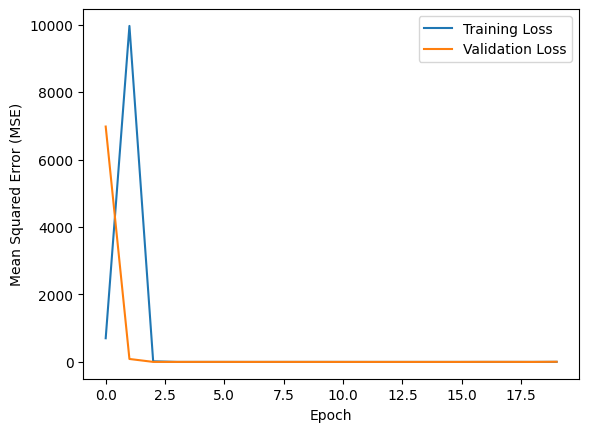

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

In [ ]:
# Convert the best loss to percentage
percentage_loss = (best_loss / (df['AC_POWER'].max() - df['AC_POWER'].min())) * 100
print(f"Best Model Test : {best_model_LSTM}")  # Print the original loss
print(f"Best Model Test Loss: {best_loss}")  # Print the original loss
print(f"Best Model Test Loss Percentage: {percentage_loss}%") # Print the percentage loss

Best Model Test : <Sequential name=sequential_3, built=True>
Best Model Test Loss: 0.3871079981327057
Best Model Test Loss Percentage: 0.028727297775136593%


In [ ]:
# Make predictions using the best model
predictions_best_model = best_model_LSTM.predict(X_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


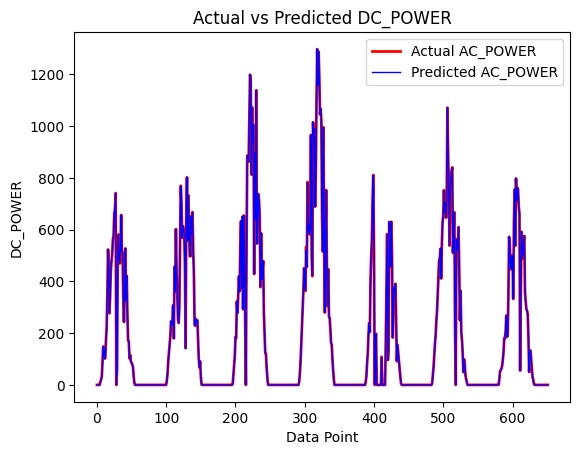

In [ ]:
# Flatten the arrays to 1D
y_test_flat = y_test.flatten()
predictions_flat = predictions_best_model.flatten()

# Create a color for the actual line (red) and predicted line (yellow)
color_actual = 'red'
color_predicted = 'blue'

# Plot the actual line in red
plt.plot(y_test_flat, color=color_actual, label='Actual AC_POWER', linewidth=2)

# Plot the predicted line in yellow
plt.plot(predictions_flat, color=color_predicted, label='Predicted AC_POWER', linewidth=1)

plt.xlabel('Data Point')
plt.ylabel('DC_POWER')
plt.title('Actual vs Predicted DC_POWER')
plt.legend()
plt.show()

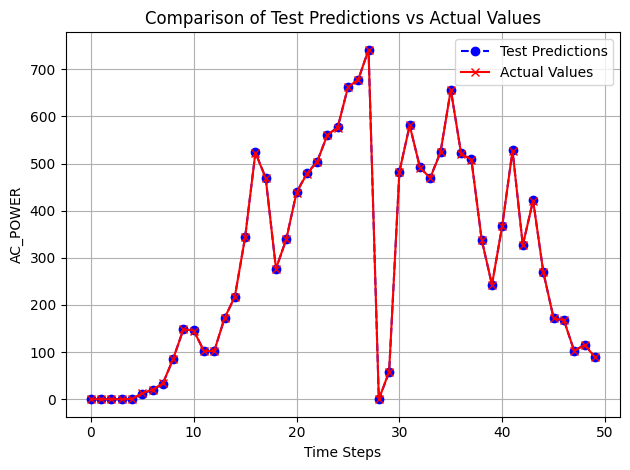

In [ ]:
import matplotlib.pyplot as plt

# Plot Test Predictions and Actual Values
plt.plot(y_pred[:50], label='Test Predictions', color='blue', linestyle='--', marker='o')
plt.plot(y_test[:50], label='Actual Values', color='red', linestyle='-', marker='x')

# Add labels, title, and grid
plt.title('Comparison of Test Predictions vs Actual Values')
plt.xlabel('Time Steps')
plt.ylabel('AC_POWER')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = best_model_LSTM.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Mean Squared Error: 0.38710811200564277
Root Mean Squared Error: 0.6221801282632248
Mean Absolute Error: 0.24049033106344733
R-squared: 0.9999955026368395


In [ ]:
best_model_LSTM.metrics_names

['loss']

In [ ]:
from sklearn.metrics import r2_score

y_train_pred = best_model_LSTM.predict(X_train)
y_test_pred = best_model_LSTM.predict(X_test)

train_score = r2_score(y_train, y_train_pred)
test_score = r2_score(y_test, y_test_pred)

print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Train Score: 0.9999985491612486
Test Score: 0.9999955026368395


In [ ]:
best_model_LSTM.evaluate(X_test,y_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3489


0.3871079981327057

In [ ]:
df.tail(1)

,DC_POWER,AC_POWER,DAILY_YIELD,MODULE_TEMPERATURE,HOUR,MINUTE
DATE_TIME,,,,,,
2020-06-17 23:45:00,0.0,0.0,4258.0,22.535908,23,45


In [ ]:
X_train.shape

(2607, 1, 4)

In [ ]:
y_train.shape

(2607, 1)

In [ ]:
X_test.shape

(652, 1, 4)

In [ ]:
y_test.shape

(652, 1)

In [ ]:
X_scaled.shape

(2607, 4)

In [ ]:
print(y_test[20])
print(y_pred[20])

[438.24666667]
[438.99466]


In [ ]:
print(y_test[600])
print(y_pred[600])

[500.66]
[501.52377]


In [ ]:
print(y_test[416])
print(y_pred[416])

[0.]
[-0.02902853]


In [ ]:
print(y_test[132])
print(y_pred[132])

[732.97333333]
[732.9137]


In [ ]:
print(y_test[1])
print(y_pred[1])

[0.]
[-0.02902853]


In [ ]:
print(y_test[196])
print(y_pred[196])

[3.01333333]
[2.1007009]


In [ ]:
print(y_test[115])
print(y_pred[115])

[436.38571429]
[436.899]


In [ ]:
df_y_test = pd.DataFrame(y_test)
df_y_pred = pd.DataFrame(y_pred)

In [ ]:
df1 = pd.concat([df_y_test, df_y_pred], axis=1)
df1.columns = ['y_test', 'y_pred']

In [ ]:
df1.to_csv('Ly-test,Ly-pred.csv', index=False)

In [ ]:
sample_df = df1.sample(n=10, replace=False)

sample_df

,y_test,y_pred
79,0.000000,-0.029029
246,27.700000,26.991058
191,0.000000,-0.029029
250,0.000000,-0.029029
122,707.440000,707.242981
588,179.693333,179.227631
326,515.600000,516.048523
83,0.000000,-0.029029
519,562.193333,562.534790
554,0.000000,-0.029029


In [ ]:
y_pred.mean()

213.77037

In [ ]:
df[['AC_POWER']].describe()

,AC_POWER
count,3259.000000
mean,243.223341
std,362.711619
min,0.000000
25%,0.000000
50%,0.000000
75%,445.326667
max,1347.526667


In [ ]:
from tensorflow.keras.models import load_model
best_model_LSTM.save('best_model_LSTM.h5')

In [ ]:
loses = history.history['loss']
val_loses = history.history['val_loss']

In [ ]:
df_loss = pd.DataFrame({'loses':loses, 'val_loses':val_loses})

In [ ]:
df_loss.to_csv('df_Lloss.csv', index=False)